In [1]:
pip install "sweetviz"

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   ----- ---------------------------------- 2.1/15.1 MB 13.0 MB/s eta 0:00:02
   ----------- ---------------------------- 4.2/15.1 MB 14.0 MB/s eta 0:00:01
   ---------------- ----------------------- 6.3/15.1 MB 11.0 MB/s eta 0:00:01
   ------------------- -------------------- 7.3/15.1 MB 10.5 MB/s eta 0:00:01
   ------------------------ --------------- 9.4/15.1 MB 9.8 MB/s eta 0:00:01
   --------------------------- ------------ 10.5/15.1 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------  14.9/15.1 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 15.1/15.1 MB 10.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importando as bibliotecas que serão utilizadas no python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import sweetviz as sv
from matplotlib.cbook import boxplot_stats
warnings.filterwarnings("ignore", category=FutureWarning)
import pandoc


In [3]:
#Importando as bibliotecas que serão utilizadas no python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import sweetviz as sv
from matplotlib.cbook import boxplot_stats
warnings.filterwarnings("ignore", category=FutureWarning)
import pandoc


In [4]:
#Importando o dataset 'titanic' utilizando o seaborn
df_titanic_bruto = sns.load_dataset('titanic')

#Printando o cabeçalho do dataset
print(df_titanic_bruto.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Análise Estatística Básica

In [5]:
#Obtendo informações de cada coluna do dataset
print('Informações do dataset')
df_titanic_bruto.info()


Informações do dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


* Observando as informações dos dados do dataset, é poossível visualizar que ha dados do tipo boleano, ionteiro, categóricos etc.

* São no total 13 colunas e 891 linhas (entradas)

* Chama a atenção que algumas colunas como a coluna age e deck possuem valores nulos ou faltantes

In [6]:
#Obtendo sumário estatístico do dataset
print('Sumário Estatístico')
df_titanic_bruto.describe()

Sumário Estatístico


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* Nesse sumário estatístico é possível observar algumas informações do dataset, primeiro a média dos valores numéricos de cada coluna, a mediana (qaurtil 50%), o desvio padrão, o valor mínimo e máximo, bem como os quartis.

* Análise dos quartis coluna age: 25% dos das pessoas tinham idade igual ou inferior a 20,125 anos, 50% tinha idade igual ou menor a 28 anos, e 75% das pessoas tinham 38 anos ou menos e assim por diante nas outras colunas.

* Analisando os valores mássimos e mínimos das tarifas na coluna fare, observamos qe o a média do preço das passagens foi de 32,20$, enquanto o valor minimo foi de zero e o maior foi de 512,32 dólares. Inicialmente, o, alto desvio padrão de aproximadamente 49,69 dólares na variável fare indica uma grande dispersão nas tarifas pagas pelos passageiros. Isso sugere a presença de outliers (valores extremos), que estão puxando a média para cima, já que ela (32,20) está muito acima da mediana (14,45). A diferença acentuada entre média e mediana, aliada à alta variabilidade, reforça a hipótese de assimetria positiva e valores discrepantes na distribuição.

In [7]:
#Obtendo a quantidade de valores null por oluna
df_titanic_bruto.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

* O output acima mostra a quantidade de valores nulos nas colunas do dataset, como é possível observar, a coluna deck possui muitos valores nulos, praticamente impossibilitando o tratamento de dados.

In [8]:
#Percentual de nulos por coluna
percentual_nulos = df_titanic_bruto.isnull().sum() / len(df_titanic_bruto.index) * 100
print(percentual_nulos, 3*'\n')

#Filtrando para mostrar somente colunas que possuem percentual de valores nulos maiores do que zero
percentual_nulos_maior_zero = percentual_nulos[percentual_nulos > 0]


survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64 





* Aqui é possivel verificar que o percentual de valores nulos na coluna deck ultrapassa 75% dos registros

Mostrando colunas com nulos em que o percentual é maior do que zero 
 age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


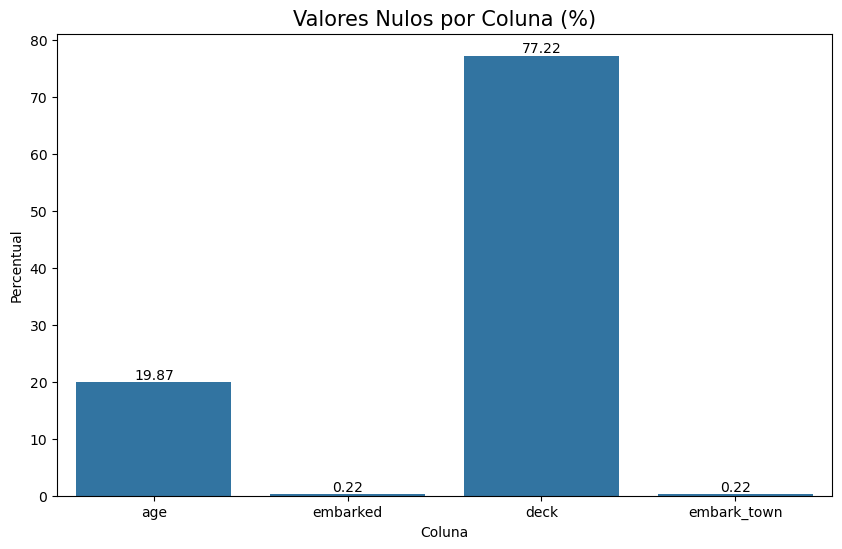

In [9]:
plt.figure(figsize=(10, 6))
nulos_maior_0 = sns.barplot(
    x=percentual_nulos_maior_zero.index,
    y=percentual_nulos_maior_zero.values,)
print('Mostrando colunas com nulos em que o percentual é maior do que zero \n' , percentual_nulos_maior_zero)

#Formatando rótulos de dados
for p in nulos_maior_0.patches:
    nulos_maior_0.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Valores Nulos por Coluna (%)', size = 15)
plt.ylabel('Percentual')
plt.xlabel('Coluna')
plt.show()

In [10]:
#proporção de passageiros por classe
contagem_classe = df_titanic_bruto['pclass'].value_counts()
print(contagem_classe, df_titanic_bruto['pclass'].value_counts(normalize=True))

pclass
3    491
1    216
2    184
Name: count, dtype: int64 pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [11]:
#Perceual de passageiros viajando sozinhos
sozinho = (df_titanic_bruto['alone'] == True).value_counts(normalize=True)
print(sozinho)

alone
True     0.602694
False    0.397306
Name: proportion, dtype: float64


In [12]:
#Quantidade de embarqes por cidade 
print(df_titanic_bruto['embark_town'].value_counts())

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


In [13]:
#proporção de homens/mulheres
print(df_titanic_bruto['sex'].value_counts())

sex
male      577
female    314
Name: count, dtype: int64


In [14]:
#proporção de homens/mulheres
sexo = (df_titanic_bruto['sex'] == 'male').value_counts(normalize=True)
print(sexo)


sex
True     0.647587
False    0.352413
Name: proportion, dtype: float64


* Aqui tem-se algumas informações de colunas individuais, por exemplo o percentual de pessoas viajando sozinhas era de 60,26% e a proporção de homens abordo do navio era de 64,75%

# Tratamento de Dados

In [15]:
#Criando novo df o qual será utilizado para tratar os dados
df_titanic = df_titanic_bruto
#verificando qual o tipo de dados nulos existem nas colunas
colunas_com_nulos = ['age','deck','embarked','embark_town']
tipos_nulos = df_titanic[colunas_com_nulos][df_titanic[colunas_com_nulos].isnull().any(axis=1)]
print(tipos_nulos,'\n')

      age deck embarked  embark_town
0    22.0  NaN        S  Southampton
2    26.0  NaN        S  Southampton
4    35.0  NaN        S  Southampton
5     NaN  NaN        Q   Queenstown
7     2.0  NaN        S  Southampton
..    ...  ...      ...          ...
884  25.0  NaN        S  Southampton
885  39.0  NaN        Q   Queenstown
886  27.0  NaN        S  Southampton
888   NaN  NaN        S  Southampton
890  32.0  NaN        Q   Queenstown

[709 rows x 4 columns] 



In [16]:
#Verificando a qualidade dos dados
idades_unicas = sorted(df_titanic['age'].dropna().unique())
print(idades_unicas)

[0.42, 0.67, 0.75, 0.83, 0.92, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 14.5, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 20.5, 21.0, 22.0, 23.0, 23.5, 24.0, 24.5, 25.0, 26.0, 27.0, 28.0, 28.5, 29.0, 30.0, 30.5, 31.0, 32.0, 32.5, 33.0, 34.0, 34.5, 35.0, 36.0, 36.5, 37.0, 38.0, 39.0, 40.0, 40.5, 41.0, 42.0, 43.0, 44.0, 45.0, 45.5, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 55.5, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 70.0, 70.5, 71.0, 74.0, 80.0]


In [17]:
#substituindo dados nulos na coluna Idade pela mediana da idade:

#calculando Mediana
mediana_idades = df_titanic["age"].median()
print(f'A mediana das Idades é {mediana_idades} anos')

#Substituindo os valores nulos pela mediana
df_titanic["age"] = df_titanic["age"].fillna(mediana_idades)
df_titanic["age"].info()



A mediana das Idades é 28.0 anos
<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: age
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [18]:
#removendo a coluna "deck" e preenchendo valores faltantes na coluna "Embarked" pela moda.

#removendo coluna "deck"
df_titanic = df_titanic.drop(["deck"], axis = 1)

#moda da coluna "Embarked":
moda_embarked = df_titanic["embarked"].mode()
moda_embark_town = df_titanic["embark_town"].mode()

#subistitundo velores faltantes nas colunas:
df_titanic["embarked"] = df_titanic["embarked"].fillna(moda_embarked)
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(moda_embark_town)

#conferindo resultados:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [19]:
#Obtendo sumário estatístico do dataset após o tratamento de dados
print('Sumário Estatístico')
df_titanic.describe()


Sumário Estatístico


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* O tratamento de dados resultou na preenchimento dos valores ausentes em age, elevando o total de registros de 714 para 891.

* Houve redução no desvio padrão, indicando uma distribuição menos dispersa.

* A média e os quartis sofreram pequenas alterações, mas mantiveram a tendência geral da idade dos passageiros.

* O novo 75% (35 anos) indica que mais pessoas com idades menores foram incluídas no preenchimento dos dados ausentes.

*  O tratamento de dados, sobretudo na coluna age resultou na redução da dispersão (menor desvio padrão) e ajuste leve nos quartis.

# Testando Sweetviz após tratamento dos dados

In [20]:
job_report = sv.analyze(df_titanic)
job_report.show_html()

                                             |                                             | [  0%]   00:00 ->…

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Análise de Outliers

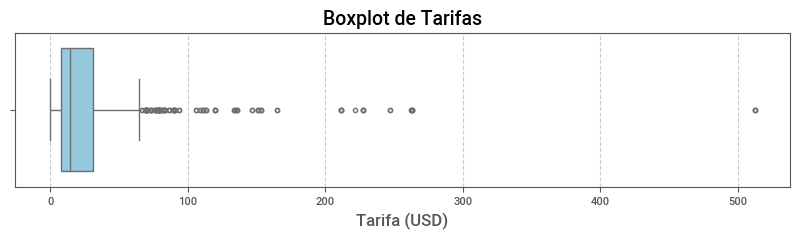

Último valor dentro do boxplot (bigode superior): $65.00


In [21]:
#Boxplot de Fare
plt.figure(figsize=(10, 2))
sns.boxplot(x='fare', data=df_titanic, color='skyblue')
plt.title('Boxplot de Tarifas', fontsize=14)
plt.xlabel('Tarifa (USD)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

boxplot_stats_tarifa = boxplot_stats(df_titanic['fare'].dropna())[0]

# encontrando ultimo valor dentro do bigode superior do boxplot
limite_superior_visual = boxplot_stats_tarifa['whishi']
print(f"Último valor dentro do boxplot (bigode superior): ${limite_superior_visual:.2f}")



* Observando os o boxplot, verifica-se que há outiliers absurdamente discrepantes em relação a distribuição dos dados, uma vez que o valor mais alto dentro do limite superior do bigode é $65

In [22]:
#Criando novo df somente com os outliars de tarifa
outliers_tarifa = df_titanic[df_titanic['fare'] > 65][['age', 'pclass', 'sex', 'survived', 'fare', 'embark_town']].copy()
print("Passageiros com tarifa > $65:\n",outliers_tarifa)

Passageiros com tarifa > $65:
       age  pclass     sex  survived      fare  embark_town
1    38.0       1  female         1   71.2833    Cherbourg
27   19.0       1    male         0  263.0000  Southampton
31   28.0       1  female         1  146.5208    Cherbourg
34   28.0       1    male         0   82.1708    Cherbourg
52   49.0       1  female         1   76.7292    Cherbourg
..    ...     ...     ...       ...       ...          ...
846  28.0       3    male         0   69.5500  Southampton
849  28.0       1  female         1   89.1042    Cherbourg
856  45.0       1  female         1  164.8667  Southampton
863  28.0       3  female         0   69.5500  Southampton
879  56.0       1  female         1   83.1583    Cherbourg

[116 rows x 6 columns]


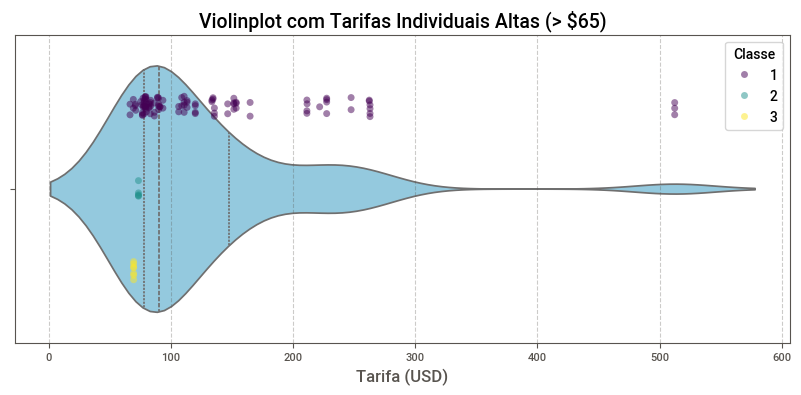

In [23]:
#gráfico de violido com stripplot
plt.figure(figsize= (10, 4))
sns.violinplot(x= 'fare', data = outliers_tarifa, color = 'skyblue', inner = 'quartile')
sns.stripplot(x = 'fare', hue = 'pclass', data = outliers_tarifa, palette = 'viridis', alpha = 0.5, jitter = True, dodge=True)
plt.title('Violinplot com Tarifas Individuais Altas (> $65)', fontsize=14)
plt.xlabel('Tarifa (USD)', fontsize = 12)
plt.grid(axis = 'x', linestyle = '--', alpha = 0.3)
plt.legend(title='Classe')
plt.show()


* O violinplot mostra a densidade de passageiros por faixa de preço, indicando onde há maior ou menor concentração de tarifas. As linhas verticais dentro da figura representam os quartis da distribuição (somente outliers da coluna fare)
  
* Vizalizando o gráfico, é possível constatar que a maior parte dos passageiros com tarifas acima de $65 pertence à 1ª classe, o que é esperado, dado o luxo e os privilégios oferecidos a esses viajantes. Há poucos passageiros da 2ª e quase nenhum da 3ª classe nessa faixa de preço.

In [24]:
# Definindo intervalos entre as tarifas
condicoes = [
    (outliers_tarifa['fare'] < 101),
    (outliers_tarifa['fare'] >= 101) & (outliers_tarifa['fare'] <= 200),
    (outliers_tarifa['fare'] > 200) & (outliers_tarifa['fare'] <= 300),
    (outliers_tarifa['fare'] > 300)
]

categorias = ['0-100', '101-200', '201-300', '300 >']

# Criando a nova coluna
outliers_tarifa['intervalo_tarifa'] = np.select(condicoes, categorias)

# Estatísticas por intervalo
estatisticas_outliers = outliers_tarifa.groupby('intervalo_tarifa')['fare'].agg(['count', 'min', 'max', 'mean'])
print(estatisticas_outliers)


                  count       min       max        mean
intervalo_tarifa                                       
0-100                63   66.6000   93.5000   78.874405
101-200              33  106.4250  164.8667  131.108200
201-300              17  211.3375  263.0000  238.187253
300 >                 3  512.3292  512.3292  512.329200


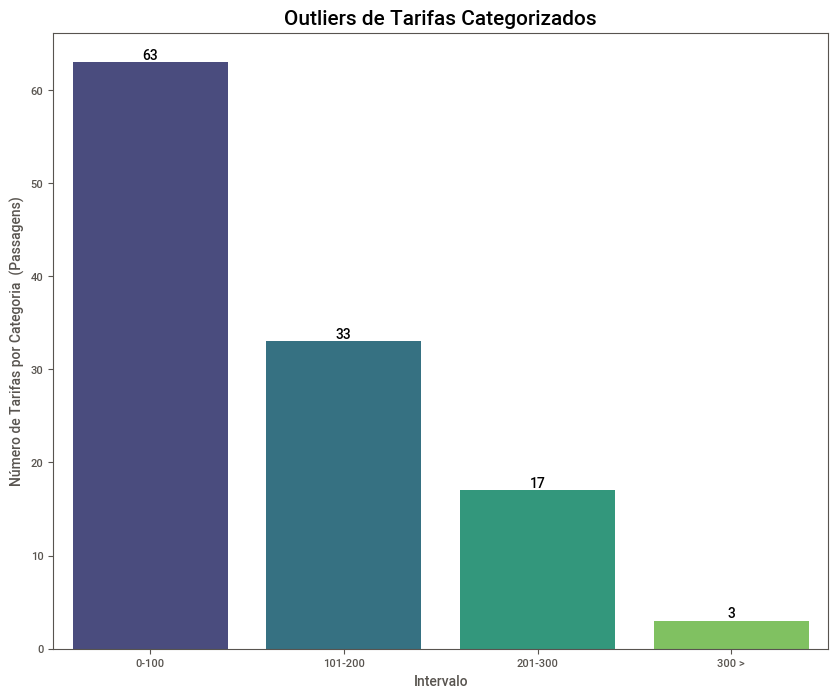

In [25]:
# Gráfico Número de Tarifas (passagens) pagas por intervalo
contagem_por_intervalo = outliers_tarifa.groupby('intervalo_tarifa')['fare'].count()

plt.figure(figsize=(10, 8))
graf_tarifa = sns.barplot(
    x=contagem_por_intervalo.index,
    y=contagem_por_intervalo.values,
    palette='viridis')

#Formatando rótulos de dados
for p in graf_tarifa.patches:
    graf_tarifa.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Outliers de Tarifas Categorizados', size = 15)
plt.ylabel('Número de Tarifas por Categoria  (Passagens)')
plt.xlabel('Intervalo')
plt.show()

* Gráfico mostrando a distibição de outliers por faixa de preço, interessante observar que cerca de 1/2 das ocorrências estão dentro do intervalo de 0-100 dólares.

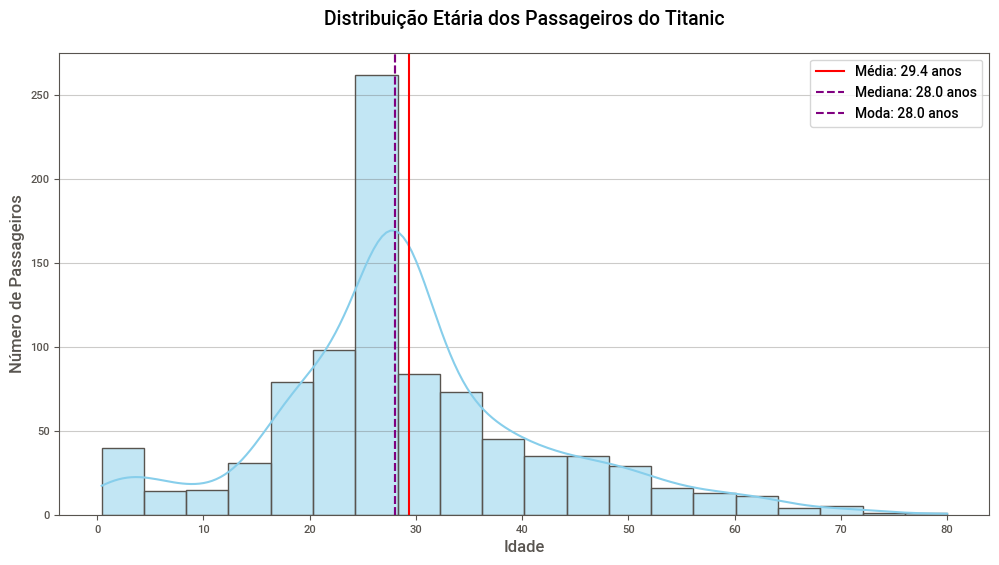

In [26]:
#Verificando a Distribuição etária da população do titanic
plt.figure(figsize=(12, 6))

#Histograma de distribuição etária
sns.histplot(data=df_titanic, x='age', bins=20, kde=True, color='skyblue')

#Configurações do gráfico
plt.title('Distribuição Etária dos Passageiros do Titanic', fontsize=14, pad=20)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Número de Passageiros', fontsize=12)
plt.grid(axis='y', alpha=0.3)

#Linhas verticais na Média, Mediana e Moda
mean_age = df_titanic['age'].mean()
plt.axvline(mean_age, color = 'red', linestyle = '-', 
            label = f'Média: {mean_age:.1f} anos')

median_age = df_titanic['age'].median()
plt.axvline(median_age, color='purple', linestyle='--', 
            label=f'Mediana: {median_age:.1f} anos')

moda_idade = df_titanic['age'].mode()[0]
plt.axvline(moda_idade, color='purple', linestyle='--', 
            label=f'Moda: {moda_idade:.1f} anos')

plt.legend()
plt.show()

* histograma da distribuição de idades do titanic, observsa-se que possui uma distribuição aproximadamente normal com assimetria à direita, a moda, média e mediana estão por volta dos 28 anos.

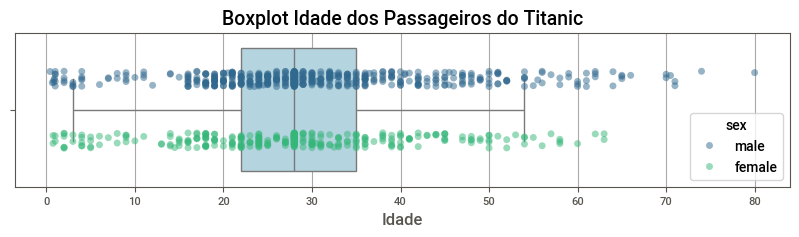

Primeiro valor dentro do boxplot (bigode inferior): 3.00 anos
Último valor dentro do boxplot (bigode superior): 54.00 anos


In [27]:
#gráfico de boxplot de Idades
plt.figure(figsize=(10, 2))
sns.boxplot(x='age', data=df_titanic, color='lightblue', showfliers=False)
sns.stripplot(x = 'age', hue = 'sex', data = df_titanic, palette = 'viridis', alpha = 0.5, jitter = True, dodge=True)
plt.title('Boxplot Idade dos Passageiros do Titanic', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.5)
plt.show()

boxplot_stats_idades = boxplot_stats(df_titanic['age'].dropna())[0]

# Obtendo os limites dos bigodes
limite_inferior_idade = boxplot_stats_idades['whislo']
limite_superior_idade = boxplot_stats_idades['whishi']
print(f"Primeiro valor dentro do boxplot (bigode inferior): {limite_inferior_idade:.2f} anos")
print(f"Último valor dentro do boxplot (bigode superior): {limite_superior_idade:.2f} anos")


* nesse boxplot observamos que há outliers superiores e inferiores, sendo valores o primeiro valor dentro do boxplot (bigode inferior): 3.00 anos 
Último valor dentro do boxplot (bigode superior): 54.00 anos

In [28]:
#Novo df com os outliars de idade
outliers_idade = df_titanic[(df_titanic['age'] > 54) | (df_titanic['age'] < 3)][['age', 'pclass', 'sex', 'survived', 'fare']].copy()
print("Passageiros com idade > 54 ou < 4:\n", outliers_idade)

Passageiros com idade > 54 ou < 4:
        age  pclass     sex  survived     fare
7     2.00       3    male         0  21.0750
11   58.00       1  female         1  26.5500
15   55.00       2  female         1  16.0000
16    2.00       3    male         0  29.1250
33   66.00       2    male         0  10.5000
..     ...     ...     ...       ...      ...
827   1.00       2    male         1  37.0042
829  62.00       1  female         1  80.0000
831   0.83       2    male         1  18.7500
851  74.00       3    male         0   7.7750
879  56.00       1  female         1  83.1583

[66 rows x 5 columns]


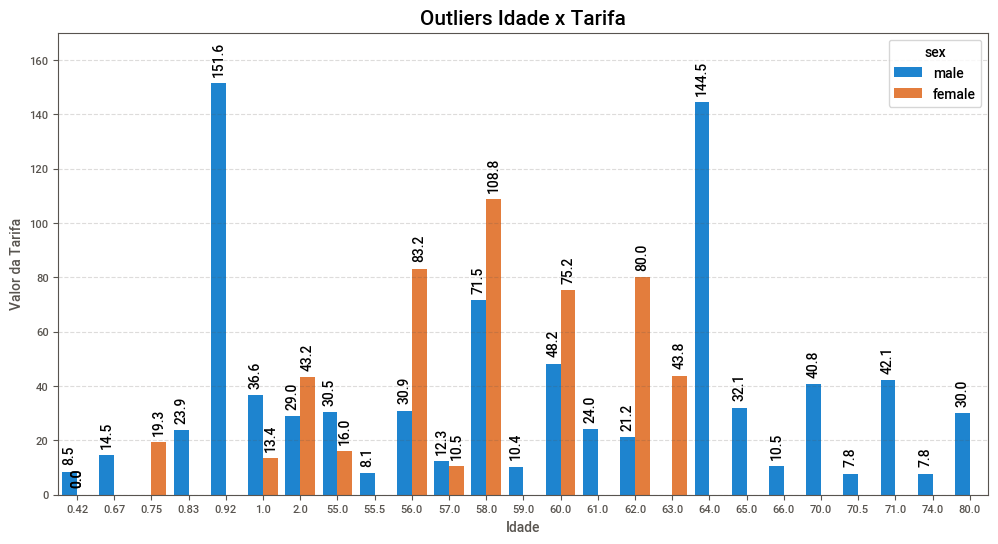

In [29]:
#Plotando grágico dos outliers de idade em relação a tarifa paga
plt.figure(figsize=(12, 6))
graf_idade_tarifa = sns.barplot(x = 'age', y = 'fare', hue = 'sex', data = outliers_idade, errorbar = None)
plt.grid(axis='y', linestyle='--', alpha=0.2)

#Formatando rótulos de dados
for p in graf_idade_tarifa.patches:
    graf_idade_tarifa.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha = 'center', va = 'bottom', 
                rotation = 90,
                xytext = (0, 5), 
                textcoords = 'offset points')
    
plt.ylim(top=170)
plt.title('Outliers Idade x Tarifa', size = 15)
plt.ylabel('Valor da Tarifa')
plt.xlabel('Idade')

plt.show()


# Análise Bivariada


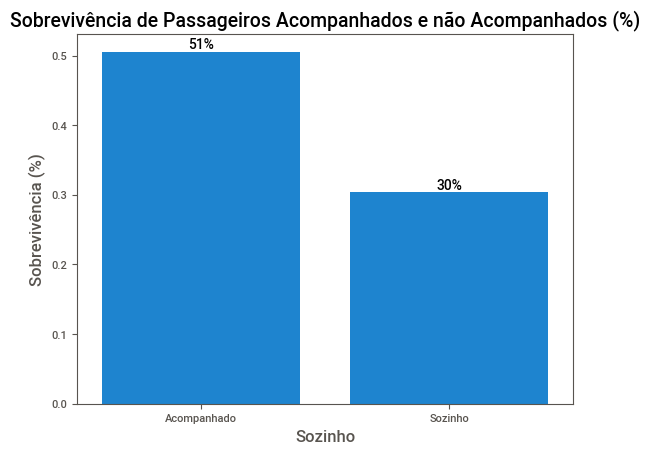

In [30]:
#Percentual de sbrevivência de passageiros que viajavam sozinhos
graf_sobrevivencia_alone = sns.barplot(x='alone', y='survived', data=df_titanic, errorbar=None)

#Formatando rótulos de dados
for p in graf_sobrevivencia_alone.patches:
    graf_sobrevivencia_alone.annotate(f'{p.get_height():.0%}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Sobrevivência de Passageiros Acompanhados e não Acompanhados (%)', fontsize=14)
plt.xlabel('Sozinho', fontsize=12)
plt.ylabel('Sobrevivência (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Acompanhado', 'Sozinho'])
plt.show()

* Verifica-se que passageiros não acompanhados tiveram taxa de sobrevivência 21 pontos percentuais menores do que quem estava viajando acompanhado, o que pode indicar que houve prioridade nos botes salva vidas para familias inteiras em detrimento a que estava sozinho.

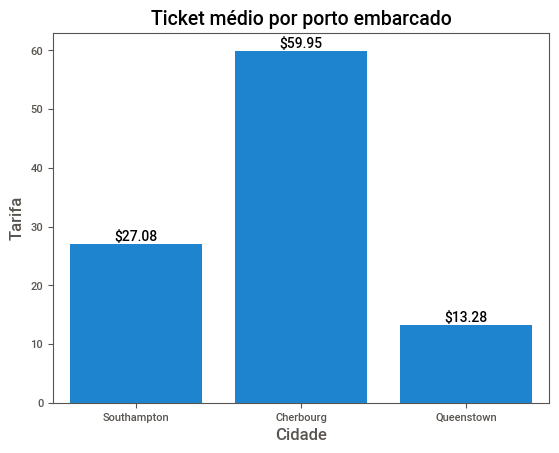

In [31]:
#Ticket Médio por cidade
graf_ticket_medio = sns.barplot(x='embark_town', y='fare', data=df_titanic, errorbar=None)

#Formatando rótulos de dados 
for p in graf_ticket_medio.patches:
    graf_ticket_medio.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Ticket médio por porto embarcado', fontsize=14)
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Tarifa', fontsize=12)
plt.show()


* Verifica-se que a cidade de cherburg teve uma tarifa média de 60 dólares, valor muito superior ao das outra cidades o que pode indicar que as pessoas que tinham outliers de tarifas embarcaram majoritáriamente nessa ciadade.

Passageiros com tarifa > $65:
       age  pclass     sex  survived      fare  embark_town intervalo_tarifa
1    38.0       1  female         1   71.2833    Cherbourg            0-100
27   19.0       1    male         0  263.0000  Southampton          201-300
31   28.0       1  female         1  146.5208    Cherbourg          101-200
34   28.0       1    male         0   82.1708    Cherbourg            0-100
52   49.0       1  female         1   76.7292    Cherbourg            0-100
..    ...     ...     ...       ...       ...          ...              ...
846  28.0       3    male         0   69.5500  Southampton            0-100
849  28.0       1  female         1   89.1042    Cherbourg            0-100
856  45.0       1  female         1  164.8667  Southampton          101-200
863  28.0       3  female         0   69.5500  Southampton            0-100
879  56.0       1  female         1   83.1583    Cherbourg            0-100

[116 rows x 7 columns]


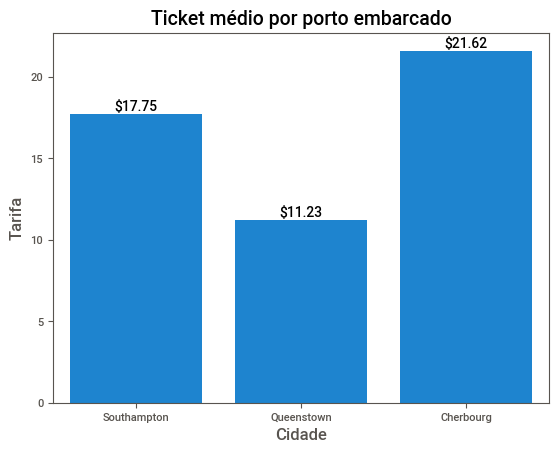

In [32]:
#Criando novo df sem os outliars de tarifa
sem_outliers_tarifa = df_titanic[df_titanic['fare'] < 65][['age', 'pclass', 'sex', 'survived', 'fare', 'embark_town']].copy()
print("Passageiros com tarifa > $65:\n",outliers_tarifa)

#Ticket Médio por cidade
graf_ticket_medio_sem_outliers = sns.barplot(x='embark_town', y='fare', data=sem_outliers_tarifa, errorbar=None)

#Formatando rótulos de dados 
for p in graf_ticket_medio_sem_outliers.patches:
    graf_ticket_medio_sem_outliers.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Ticket médio por porto embarcado', fontsize=14)
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Tarifa', fontsize=12)
plt.show()


* Após a remoção dos outliers, ficou claro que os outilers estavam puxando para cima a média de passagens na cidade de cherbourg, verificou-se também pequena redução na média das tarifas das outras cidades.

Proporção de Homens Adultos:
adult_male
True     60.3%
False    39.7%
Name: proportion, dtype: object


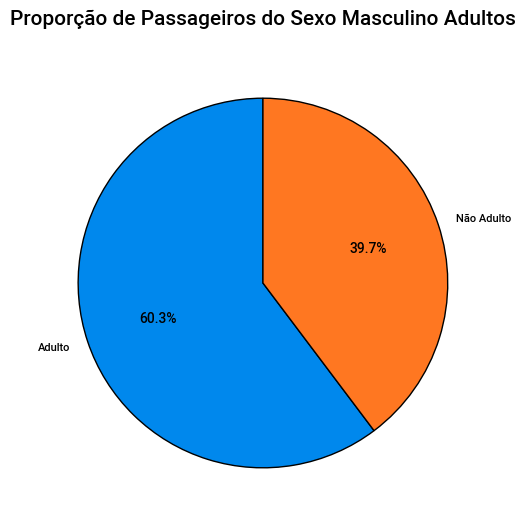

In [33]:
# Proporção de homens adultos
homem_adulto = (df_titanic['adult_male'] == True).value_counts(normalize=True) * 100

print("Proporção de Homens Adultos:")
print(homem_adulto.round(1).astype(str) + '%')

# Gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(x = homem_adulto,
        labels=['Adulto', 'Não Adulto'],
        autopct='%.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Proporção de Passageiros do Sexo Masculino Adultos', pad=20, fontsize=15)
plt.show()

* proporção da população masculina adulta no Titanic: 60,3% adulta, 39,7% não adulta.

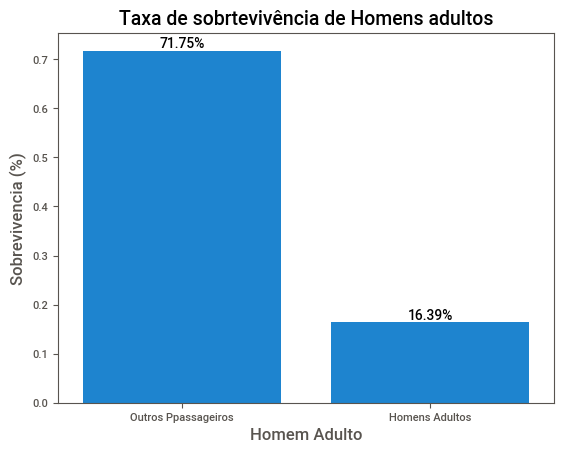

In [34]:
#Taxa de sobrevivência de homens adultos
graf_ticket_medio = sns.barplot(x='adult_male', y='survived', data=df_titanic, errorbar=None)

# Add value labels
for p in graf_ticket_medio.patches:
    graf_ticket_medio.annotate(f'{p.get_height():.02%}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Taxa de sobrtevivência de Homens adultos', fontsize=14)
plt.xlabel('Homem Adulto', fontsize=12)
plt.ylabel('Sobrevivencia (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Outros Ppassageiros', 'Homens Adultos'])
plt.show()

 * Verifica-se que a taxa de sobrevivência de homens adultos (barra laranja) foi muito inferior às demais categorias de passageiros (barra azul), isso porque à época foi dado prioridades para mulheres e crianças.

  categoria_etaria  total_pessoas  sobreviventes  taxa_sobrevivencia
0           adulto            648            238            0.367284
1          criança             83             49            0.590361
2            idoso             64             22            0.343750
3            jovem             96             33            0.343750


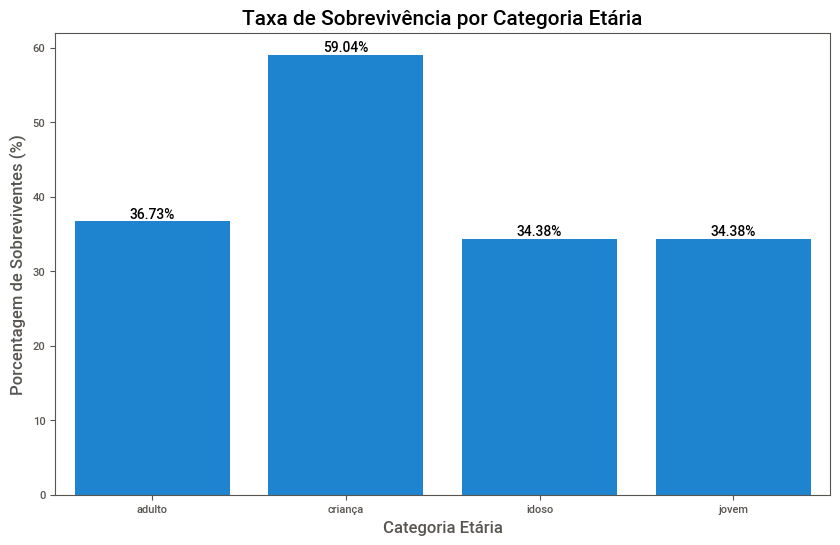

In [35]:
#taxa de sobrevivência por Idade:
# Definindo faixas etárias corretamente
condicoes = [
    (df_titanic['age'] < 16),
    (df_titanic['age'] >= 16) & (df_titanic['age'] <= 20),
    (df_titanic['age'] > 20) & (df_titanic['age'] <= 50),
    (df_titanic['age'] > 50)
]

categorias = ['criança', 'jovem', 'adulto', 'idoso']

# Criando a nova coluna
df_titanic['categoria_etaria'] = np.select(condicoes, categorias, default='desconhecido')

sobrevivencia_por_idade = df_titanic.groupby('categoria_etaria')['survived'].agg(
    total_pessoas='count',
    sobreviventes='sum',
    taxa_sobrevivencia='mean'
).reset_index()
print(sobrevivencia_por_idade)

#gráfico:
# Sobrevivência por categoria 'who' (homem, mulher, criança)
porcentagem_categoria_etaria = df_titanic.groupby('categoria_etaria')['survived'].mean() * 100

plt.figure(figsize=(10, 6))
graf_sobrevi_categ_etaria = sns.barplot(
    x=porcentagem_categoria_etaria.index,
    y=porcentagem_categoria_etaria.values
)

# Formatando Rótulo de dados
for p in graf_sobrevi_categ_etaria.patches:
    graf_sobrevi_categ_etaria.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Taxa de Sobrevivência por Categoria Etária', size = 15)
plt.xlabel('Categoria Etária', fontsize=12)
plt.ylabel('Porcentagem de Sobreviventes (%)', fontsize=12)
plt.show()

* Percentual de sobrevivência por categoria etária:
* 0 à 15 anos (barra laranja): 59,04% de sobrevivência
* 16 à 19 anos (barra vermelha): 34,38% de sobrevivência
* 20 à 49 anos (barra azul): 36,73% de sobrevivência
* 50 ou mais anos de idade (barra verde: 34,38% de sobrevivência

* O que esses dados nos dizem?
* Novamente retornamos à questão da prioridade à mulheres e crianças nos botes salva-vidas, isso explica o motivo principal da taxa de sobrevivência de crianças ser mais alta do que as demais, interessante notar também que a taxa de sobrevivência global das demais categorias ficou em torno de 34%.

Proporção por sexo:
sex
male      64.8%
female    35.2%
Name: proportion, dtype: object


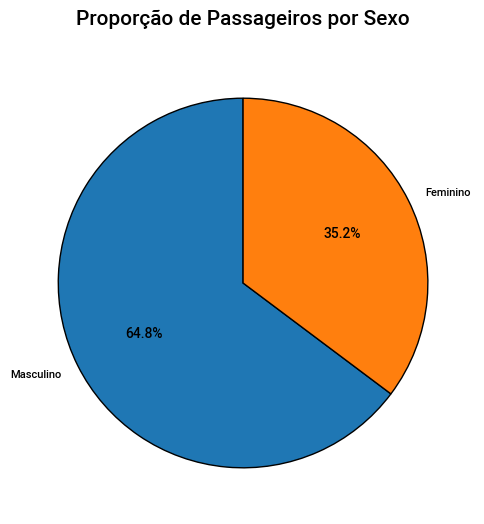

In [36]:
# Proporção de homens/mulheres
proporcao_sexo = df_titanic['sex'].value_counts(normalize=True) * 100

print("Proporção por sexo:")
print(proporcao_sexo.round(1).astype(str) + '%')

# Gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(proporcao_sexo, 
        labels=['Masculino', 'Feminino'],
        autopct='%.1f%%',
        colors=['#1f77b4', '#ff7f0e'],
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Proporção de Passageiros por Sexo', pad=20, fontsize=15)
plt.show()

* Proporção de homens e mulheres no navio, cerca de 1/3 de mulhers e 2/3 de homens.

      sex  total_pessoas  sobreviventes  taxa_sobrevivencia
0  female            314            233            0.742038
1    male            577            109            0.188908


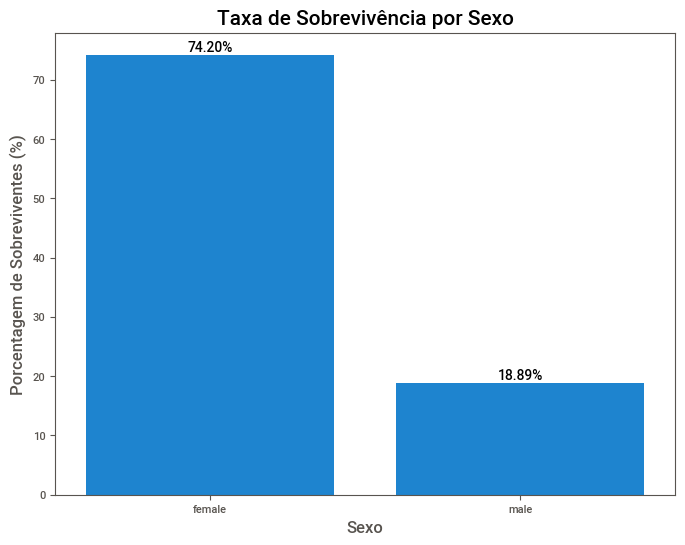

In [37]:
#taxa de sobrevivência por sexo:
sobrevivencia_por_sexo = df_titanic.groupby('sex')['survived'].agg(
    total_pessoas='count',
    sobreviventes='sum',
    taxa_sobrevivencia='mean'
).reset_index()
print(sobrevivencia_por_sexo)

#gráfico:
# Sobrevivência pela categoria sexo (Feminino, masculino)
porcentagem_sex = df_titanic.groupby('sex')['survived'].mean() * 100

plt.figure(figsize=(8, 6))
graf_sobrevi_sex = sns.barplot(
    x=porcentagem_sex.index,
    y=porcentagem_sex.values
    
)

# Formatando Rótulo de dados
for p in graf_sobrevi_sex.patches:
    graf_sobrevi_sex.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Taxa de Sobrevivência por Sexo', size = 15)
plt.ylabel('Porcentagem de Sobreviventes (%)', fontsize=12)
plt.xlabel('Sexo', fontsize=12)
plt.show()

* Basicamente pode-se dizer que 1 em cada 5 homens sobreviveram, enqanto qe a taxa de sobrevivência de mulheres foi quase 4x maior do que a taxa de sobrevivência de homens.
  
* Novamente verifica-se a prioridade de mulheres e crianças nos botes salva-vidas, nesse caso também pode-se explicar parcialmente a baixa taxa de sobrevivência de homens por conta de que os trabalhadores das salas de máquinas, que tiveram baixa sobrevivência e compunham parte considerável da tripulação.

   pclass  total_pessoas  sobreviventes  taxa_sobrevivencia
0       1            216            136            0.629630
1       2            184             87            0.472826
2       3            491            119            0.242363


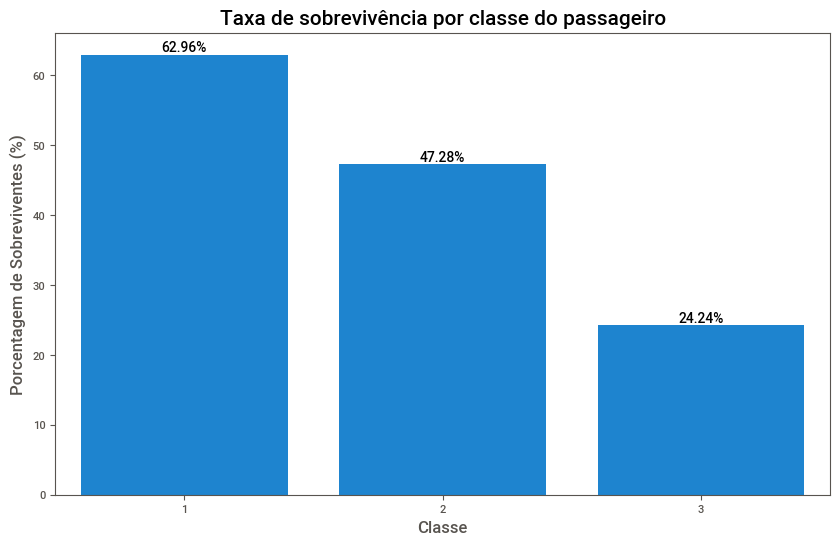

In [38]:
#taxa de sobrevivência por classe de passageiros:
sobrevivencia_por_classe = df_titanic.groupby('pclass')['survived'].agg(
    total_pessoas='count',
    sobreviventes='sum',
    taxa_sobrevivencia='mean'
).reset_index()
print(sobrevivencia_por_classe)

#Gráfico:
#Sobrevivência por classe de passageiros:
porcentagem_sex = df_titanic.groupby('pclass')['survived'].mean() * 100

plt.figure(figsize=(10, 6))
graf_sobrev_classe = sns.barplot(
    x=porcentagem_sex.index,
    y=porcentagem_sex.values
)

#Formatando Rótulo de dados
for p in graf_sobrev_classe.patches:
    graf_sobrev_classe.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.title('Taxa de sobrevivência por classe do passageiro', size = 15)
plt.ylabel('Porcentagem de Sobreviventes (%)', fontsize=12)
plt.xlabel('Classe', fontsize=12)
plt.show()

* Taxa de sobrevivência em relação à classe de passageiros, nem um poco supreendente que passageiros de primeira classe tiveram prioridade aos botes salva-vidas em relação às outras duas classes de passageiros, sendo que os passageiros da primeira classe tiverm taxa de sobrevivência aproximadamente 3x maior do que os passageiros da terceira classe, a diferença cai substâncialmente quando comparada com os passgeiros da segunda classe.

# Análise Multivariada

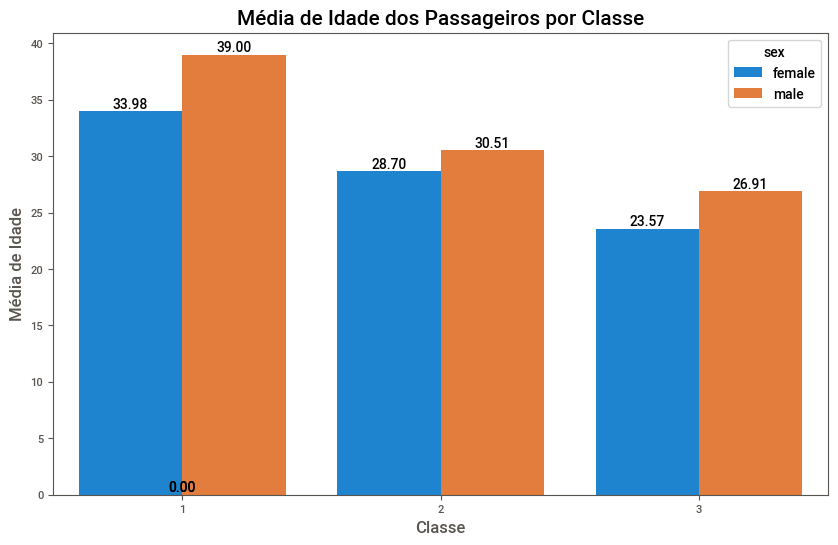

In [39]:
#Análise Multivariada
plt.figure(figsize=(10, 6))
graf_multi_1 = sns.barplot(x='pclass', y = 'age', hue='sex', data = df_titanic, errorbar = None)

#Formatando rótulos de dados
for p in graf_multi_1.patches:
    graf_multi_1.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Média de Idade dos Passageiros por Classe', size = 15)
plt.ylabel('Média de Idade', fontsize=12)
plt.xlabel('Classe', fontsize=12)
plt.show()


* Analisando brevemente o gráfico, é possível notar que a idade média dos passageiros estava correlacionada com a classe econômica, quanto mais baixa a classe, menor a média de idade dos passageiros.


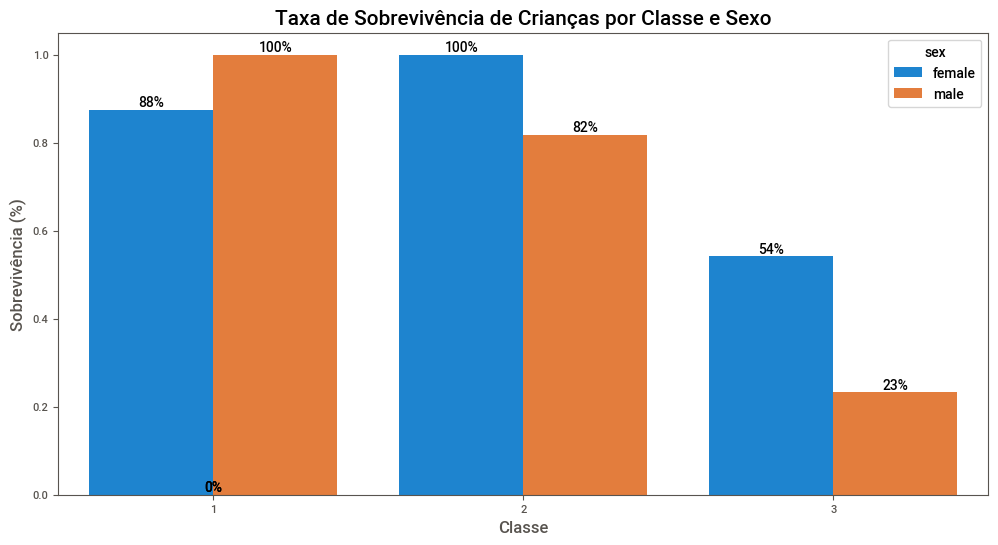

In [40]:
# Sobrevivência por classe, sexo e idade
plt.figure(figsize=(12, 6))
graf_multi_2 = sns.barplot(x='pclass', y='survived', hue='sex', 
            data=df_titanic[df_titanic['age'] < 18], errorbar=None)

#Formatando rótulos de dados
for p in graf_multi_2.patches:
    graf_multi_2.annotate(f'{p.get_height():.0%}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Taxa de Sobrevivência de Crianças por Classe e Sexo', size = 15)
plt.ylabel('Sobrevivência (%)', fontsize=12)
plt.xlabel('Classe', fontsize=12)
plt.show()

* Crianças tiveram prioridade no resgate, mas isso variou conforme classe social e sexo. As meninas das classes altas foram as mais protegidas, enquanto meninos da 3ª classe foram os mais vulneráveis.

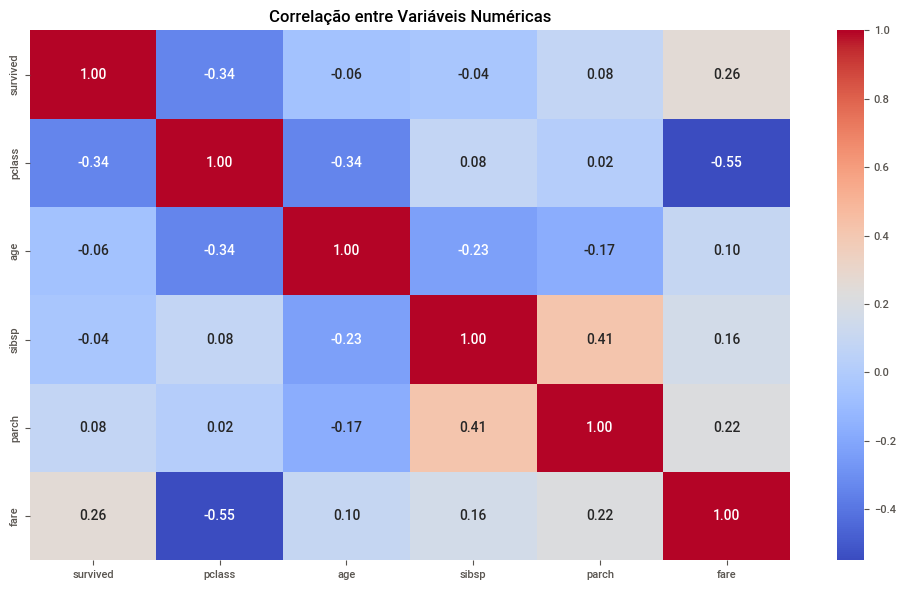

In [41]:
#Heatmap de correlação entre as variáveis numéricas:
plt.figure(figsize=(10, 6))
# Selecionar apenas colunas numéricas
colunas_numericas = df_titanic.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df_titanic[colunas_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

* Tem correlação negativa com pclass (-0.34): passageiros de classes mais altas (1ª classe) tiveram maior taxa de sobrevivência.

* Tem correlação positiva com fare (+0.26): tarifas mais altas estão associadas a maior chance de sobrevivência.

* As demais correlações com age, sibsp (irmãos/cônjuges) e parch são muito fracas.

* As variáveis com maior relação com sobrevivência foram a classe e a tarifa paga.